# Comparando Funções Preditoras


Como já foi dito em capítulos anteriores, existem diversas formas de comparar preditores. Nesse capítulo, vamos estudar um meio de fazer isso e ver mais detalhadamente as medidas de comparação presentes no Python.

## Exemplo de Comparação de Regressores

Vamos usar a base de dados faithful.

In [1]:
import pandas as pd

base = pd.read_csv("faithful.csv")

base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 272 entries, 0 to 271
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  272 non-null    int64  
 1   eruptions   272 non-null    float64
 2   waiting     272 non-null    int64  
dtypes: float64(1), int64(2)
memory usage: 6.5 KB


Note que a base apresenta apenas duas variáveis: **eruptions**, que contém uma amostra correspondente ao tempo, em minutos, que o gêiser Old Faithful permanece em erupção; e **waiting**, que contém uma amostra correspondente ao tempo, em minutos, até a próxima erupção. Vamos tentar prever a variável **waiting** por meio da variável **eruptions**. Note ainda que a variável de interesse é quantitativa contínua, portanto, queremos construir um regressor.

Vamos treinar nosso modelo utilizando 2 métodos separadamente: **Linear Model** e **k-Nearest Neighbor**. Para fazer a comparação, vamos escolher uma semente e assim tornar a comparação mais “justa”. Além disso, estamos usando toda a base de dados pra treinar o medelo, pois estamos apenas avaliando o melhor modelo.

In [2]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import cross_val_score, RepeatedKFold

base = pd.read_csv("faithful.csv")

X = base[["eruptions"]]  # Variável preditora (features)
y = base["waiting"]    # Variável alvo (target)

# Configuração da Validação Cruzada
cv = RepeatedKFold(n_splits=10, n_repeats=3, random_state=133)

# Definição dos Modelos
modelos = {
    'rl': LinearRegression(),      # Regressão Linear
    'kn': KNeighborsRegressor()    # K-Nearest Neighbors Regressor
}

# Nomes mais amigáveis para exibição dos modelos
nomes_exibicao_modelos = {
    'rl': 'LM',  # Linear Model
    'kn': 'KNN'  # K-Nearest Neighbors
}

# Definição das Métricas de Avaliação
scorings = {
    'MAE': 'neg_mean_absolute_error',        # Erro Absoluto Médio
    'RMSE': 'neg_root_mean_squared_error',   # Raiz do Erro Quadrático Médio
    'Rsquared': 'r2'                               # Coeficiente de Determinação R²
}

# Nomes mais amigáveis para exibição das métricas
nomes_exibicao_metricas = {
    'mae': 'MAE',
    'rmse': 'RMSE',
    'r2': 'Rsquared'
}

# Dicionário que armazena as métricas de cada modelo
todos_os_scores = {}

for chave_metrica, nome_scoring_sklearn in scorings.items():
    scores_para_metrica_atual = {}

    for chave_modelo, objeto_modelo in modelos.items():
        scores_cv_brutos = cross_val_score(objeto_modelo, X, y, cv=cv, scoring=nome_scoring_sklearn)
        
        # o python considera o maior valor mellhor, portanto usamos as métricas com sinal invertido e assim obtemos o menor valor
        if nome_scoring_sklearn.startswith("neg_"):
            scores_processados = -scores_cv_brutos
        else:
            scores_processados = scores_cv_brutos
            
        scores_para_metrica_atual[chave_modelo] = scores_processados # atrelando os resultados de uma métrica a um modelo
        
    todos_os_scores[chave_metrica] = scores_para_metrica_atual # envelopando os valores dos modelos dentro da respectiva métrica

# Imprime informações gerais
nomes_modelos_usados = [nomes_exibicao_modelos.get(k, k) for k in modelos.keys()]
print(f"Models: {', '.join(nomes_modelos_usados)}")
print(f"Number of resamples: {cv.get_n_splits(X, y)}")
print("-" * 30 + "\n") # Linha separadora inicial

# Itera sobre o dicionário de cada métrica
for chave_metrica, scores_dos_modelos in todos_os_scores.items():
    nome_display_metrica = nomes_exibicao_metricas.get(chave_metrica, chave_metrica)
    print(f"{nome_display_metrica}\n") # Ex: MAE, RMSE, Rsquared
    
    linhas_do_dataframe = []
    indices_do_dataframe = []

    # iterando sobre o dicionário dos modelos que contém o array de resultados de cada métrica
    for chave_modelo, array_de_scores in scores_dos_modelos.items():
        estatisticas = {
            'Min.': np.min(array_de_scores),
            '1st Qu.': np.percentile(array_de_scores, 25),
            'Median': np.median(array_de_scores),
            'Mean': np.mean(array_de_scores),
            '3rd Qu.': np.percentile(array_de_scores, 75),
            'Max.': np.max(array_de_scores),
            "NA's": int(np.sum(np.isnan(array_de_scores)))
        }
        linhas_do_dataframe.append(estatisticas)
        indices_do_dataframe.append(nomes_exibicao_modelos.get(chave_modelo, chave_modelo))

    df_da_metrica = pd.DataFrame(linhas_do_dataframe, index=indices_do_dataframe)
    
    print(df_da_metrica.to_string(header=True, index=True))
    print("\n") # Linha separadora entre métricas

Models: LM, KNN
Number of resamples: 30
------------------------------

MAE

         Min.   1st Qu.    Median      Mean   3rd Qu.      Max.  NA's
LM   3.792011  4.420689  4.783234  4.806344  5.191995  6.483631     0
KNN  3.250000  4.693452  5.118519  5.056464  5.427778  6.014815     0


RMSE

         Min.   1st Qu.    Median      Mean   3rd Qu.      Max.  NA's
LM   4.885094  5.343497  5.789113  5.890330  6.440191  7.303826     0
KNN  4.199830  5.772231  6.369425  6.203436  6.608013  7.444212     0


Rsquared

         Min.  1st Qu.    Median      Mean   3rd Qu.      Max.  NA's
LM   0.569317  0.78651  0.803728  0.797480  0.836703  0.877684     0
KNN  0.621583  0.75235  0.789425  0.776107  0.802968  0.888682     0




Repare que foi calculada três diferentes medidas: “MAE”, “RMSE”, e “Rsquared”. Nesse caso, queremos o modelo que possua MAE e RMSE baixo e $ R^2$ alto. Para vizualizar melhor, podemos construir um boxplot comparativo da seguinte forma:

In [3]:
# lista para armazenar os dicionários
valores_metricas = []

for metrica, modelo_scoring in todos_os_scores.items():
    for modelo, array_resultados_metrica in modelo_scoring.items():

        # percorre a lista com os valores de cada métrica e adiciona ao dicionário
        for score in array_resultados_metrica:
            valores_metricas.append({
                "modelo": nomes_exibicao_modelos.get(modelo, modelo),
                "metrica": nomes_exibicao_metricas.get(metrica, metrica),
                "scoring": score
            })

valores_metricas_df = pd.DataFrame(valores_metricas)

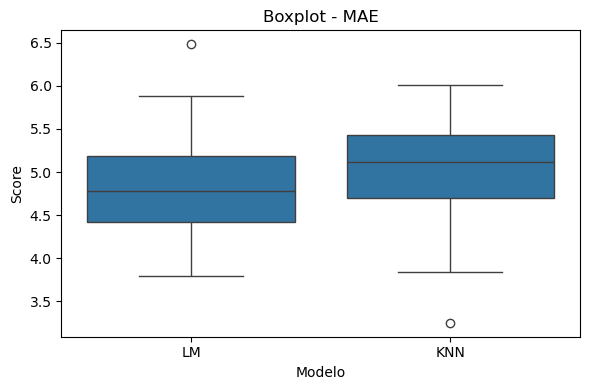

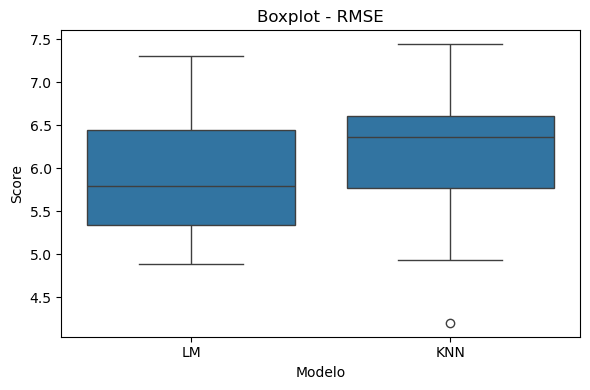

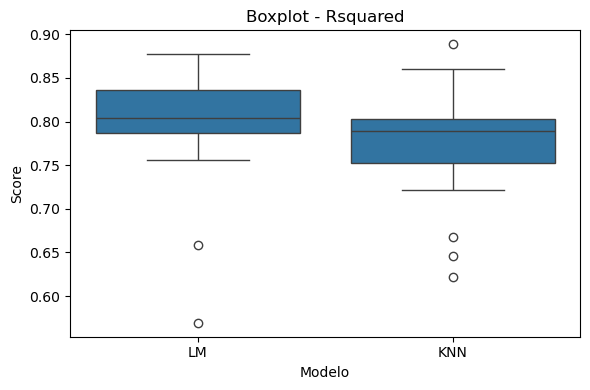

In [4]:
import matplotlib.pyplot as plt
import seaborn as sn

metricas = valores_metricas_df["metrica"].unique()

for metrica in metricas:
    plt.figure(figsize=(6, 4))
    subset = valores_metricas_df[valores_metricas_df["metrica"] == metrica]
    sn.boxplot(data=subset, x="modelo", y="scoring")
    plt.title(f"Boxplot - {metrica}")
    plt.xlabel("Modelo")
    plt.ylabel("Score")
    plt.tight_layout()
    plt.show()

Os boxplots revelam que o modelo linear apresenta a uma mediana ruim nas três métricas comparativas, com os dados mais dispersos, especialmente no $R^2$, indicando alta variabilidade. Em contrapartida, o KNN mostra uma concentração maior dos dados no RMSE e no $R^2$.